In [8]:
import os
import sys

if os.getcwd().endswith('notebook'):
    os.chdir('..')

if os.getcwd() not in sys.path:
    sys.path.append(os.getcwd())

print(f"Current working directory set to: {os.getcwd()}")

Current working directory set to: /home/nikodem/Workspace/3-sem-mgr/eapgt


In [10]:
import os
import yaml
import torch
from src.models.graphgps.model import GraphGPSModel

config_path = "./config/eap/graphgps_ba_mpnn.yaml" 
with open(config_path, 'r') as f:
    config = yaml.safe_load(f)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = GraphGPSModel(config).to(device)

checkpoint_path = config['model']['checkpoint_path']

if os.path.exists(checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f"Successfully loaded checkpoint from {checkpoint_path}\n")
else:
    raise RuntimeException(f"Warning: Checkpoint not found at {checkpoint_path}\n")


print("--- Model Modules Tree ---")
for name, module in model.named_modules():
    if name == "": continue 
    print(f"{name}: {module.__class__.__name__}")

Successfully loaded checkpoint from ./checkpoints/ba_shapes_graphdps/checkpoint_epoch_20.pt

--- Model Modules Tree ---
encoder: FeatureEncoder
encoder.node_encoder: Linear
encoder.pe_encoder: Linear
layers: ModuleList
layers.0: GPSConv
layers.0.conv: ResGatedGraphConv
layers.0.conv.aggr_module: SumAggregation
layers.0.conv.act: Sigmoid
layers.0.conv.lin_key: Linear
layers.0.conv.lin_query: Linear
layers.0.conv.lin_value: Linear
layers.0.conv.lin_skip: Linear
layers.0.attn: MultiheadAttention
layers.0.attn.out_proj: NonDynamicallyQuantizableLinear
layers.0.mlp: Sequential
layers.0.mlp.0: Linear
layers.0.mlp.1: ReLU
layers.0.mlp.2: Dropout
layers.0.mlp.3: Linear
layers.0.mlp.4: Dropout
layers.0.norm1: BatchNorm
layers.0.norm1.module: BatchNorm1d
layers.0.norm2: BatchNorm
layers.0.norm2.module: BatchNorm1d
layers.0.norm3: BatchNorm
layers.0.norm3.module: BatchNorm1d
layers.1: GPSConv
layers.1.conv: ResGatedGraphConv
layers.1.conv.aggr_module: SumAggregation
layers.1.conv.lin_key: Linear


In [11]:
import os
import torch
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import networkx as nx

sns.set_theme(style="whitegrid", palette="muted")

save_dir = "./outputs/eap_results/ba_shapes/graphgps/only_mpnn/"
artifact_path = os.path.join(save_dir, "global_attributions.pt") 

raw_scores = torch.load(artifact_path, map_location="cpu")

scores_dict = {name: score.sum().item() for name, score in raw_scores.items()}

df = pd.DataFrame(list(scores_dict.items()), columns=['Module', 'EAP_Score'])
df = df.sort_values(by='EAP_Score', ascending=False).reset_index(drop=True)

print(f"Loaded {len(df)} modules.")
display(df.head())

Loaded 100 modules.


,Module,EAP_Score
0,layers.1.attn,49.233231
1,layers.0.conv.U,48.456203
2,layers.0.conv.A,45.722984
3,layers.2.attn,41.569893
4,layers.3.attn,37.926998


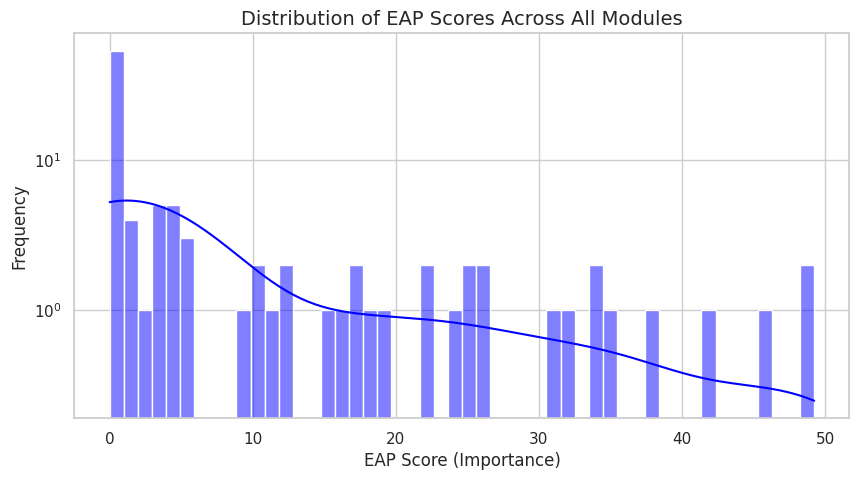

In [12]:
plt.figure(figsize=(10, 5))
sns.histplot(df['EAP_Score'], bins=50, kde=True, color='blue')
plt.title("Distribution of EAP Scores Across All Modules", fontsize=14)
plt.xlabel("EAP Score (Importance)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.yscale('log') 
plt.show()

/tmp/ipykernel_30118/1129812146.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=layer_scores, x='Layer', y='EAP_Score', palette='viridis')


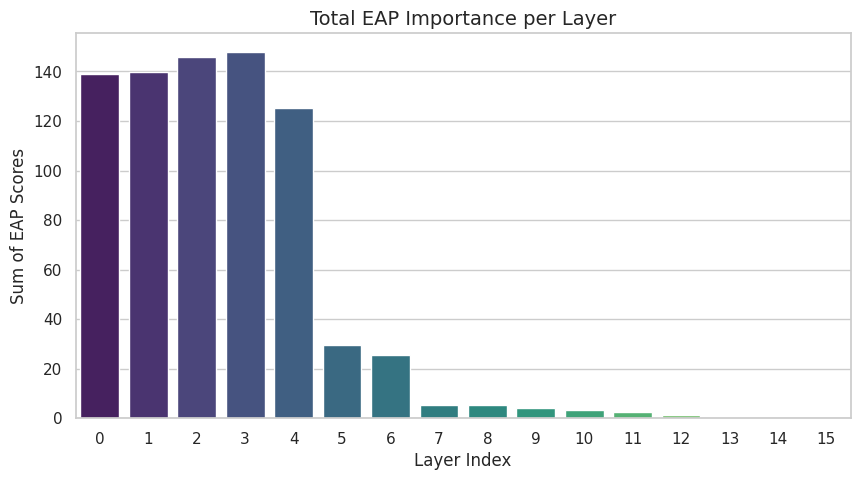

In [13]:
import re

def extract_layer(name):
    match = re.search(r'layers\.(\d+)', name)
    return int(match.group(1)) if match else -1

df['Layer'] = df['Module'].apply(extract_layer)

layer_df = df[df['Layer'] != -1]

layer_scores = layer_df.groupby('Layer')['EAP_Score'].sum().reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=layer_scores, x='Layer', y='EAP_Score', palette='viridis')
plt.title("Total EAP Importance per Layer", fontsize=14)
plt.xlabel("Layer Index", fontsize=12)
plt.ylabel("Sum of EAP Scores", fontsize=12)
plt.show()

/tmp/ipykernel_30118/233449299.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=layer_mpnn_scores, x='Layer', y='EAP_Score', palette='magma')


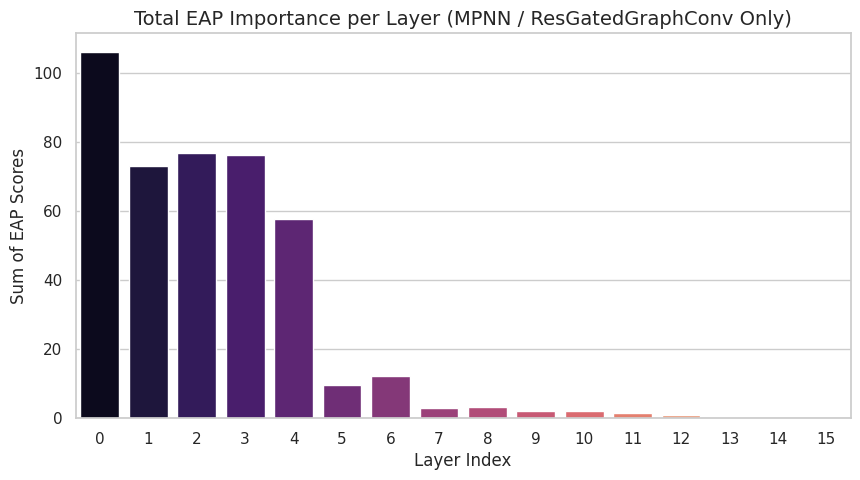

In [14]:
import re
import matplotlib.pyplot as plt
import seaborn as sns

mpnn_df = df[df['Module'].str.endswith(('.M', '.A', '.U'))].copy()

def extract_layer(name):
    match = re.search(r'layers\.(\d+)', name)
    return int(match.group(1)) if match else -1

mpnn_df['Layer'] = mpnn_df['Module'].apply(extract_layer)

layer_mpnn_df = mpnn_df[mpnn_df['Layer'] != -1]

layer_mpnn_scores = layer_mpnn_df.groupby('Layer')['EAP_Score'].sum().reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=layer_mpnn_scores, x='Layer', y='EAP_Score', palette='magma')

plt.title("Total EAP Importance per Layer (MPNN / ResGatedGraphConv Only)", fontsize=14)
plt.xlabel("Layer Index", fontsize=12)
plt.ylabel("Sum of EAP Scores", fontsize=12)
plt.show()

/tmp/ipykernel_30118/4269669866.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=mpnn_df, x='Component', y='EAP_Score',


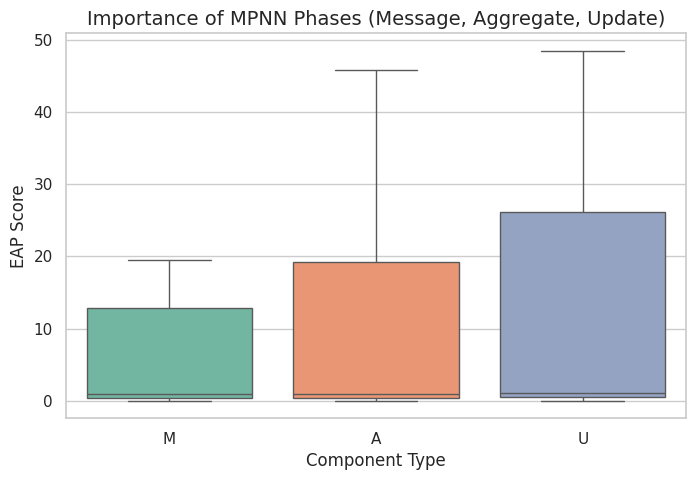

Average EAP Score per Component:


,Component,EAP_Score
0,A,9.289015
1,M,5.704692
2,U,11.606099


In [15]:
mpnn_df = df[df['Module'].str.endswith(('.M', '.A', '.U'))].copy()

mpnn_df['Component'] = mpnn_df['Module'].apply(lambda x: x[-1])

plt.figure(figsize=(8, 5))
sns.boxplot(data=mpnn_df, x='Component', y='EAP_Score', 
            order=['M', 'A', 'U'], palette='Set2')
plt.title("Importance of MPNN Phases (Message, Aggregate, Update)", fontsize=14)
plt.xlabel("Component Type", fontsize=12)
plt.ylabel("EAP Score", fontsize=12)
plt.show()

component_stats = mpnn_df.groupby('Component')['EAP_Score'].mean().reset_index()
print("Average EAP Score per Component:")
display(component_stats)

/tmp/ipykernel_30118/150438780.py:10: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df[df['Macro_Type'] != 'Other'],
/tmp/ipykernel_30118/150438780.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df[df['Macro_Type'] != 'Other'],


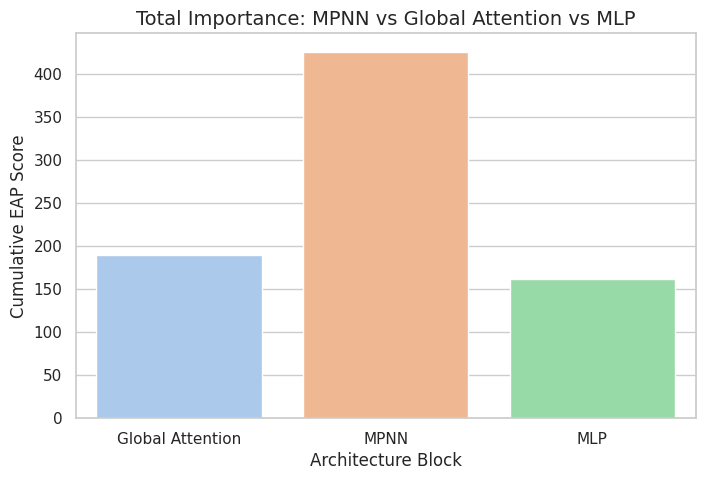

In [16]:
def classify_macro_type(name):
    if name.endswith(('.M', '.A', '.U')): return 'MPNN'
    if 'attn' in name or 'MultiheadAttention' in name: return 'Global Attention'
    if 'mlp' in name or 'ffn' in name: return 'MLP'
    return 'Other'

df['Macro_Type'] = df['Module'].apply(classify_macro_type)

plt.figure(figsize=(8, 5))
sns.barplot(data=df[df['Macro_Type'] != 'Other'], 
            x='Macro_Type', y='EAP_Score', estimator=sum, ci=None, palette='pastel')
plt.title("Total Importance: MPNN vs Global Attention vs MLP", fontsize=14)
plt.ylabel("Cumulative EAP Score", fontsize=12)
plt.xlabel("Architecture Block", fontsize=12)
plt.show()

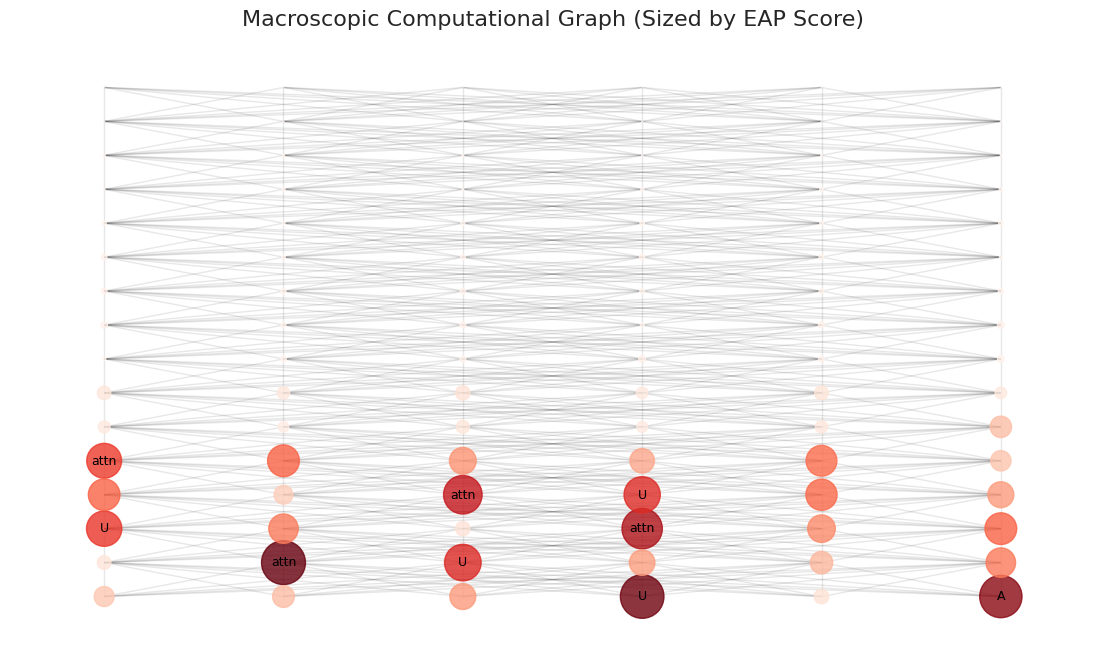

In [17]:
G = nx.DiGraph()

for _, row in layer_df.iterrows():
    G.add_node(row['Module'], layer=row['Layer'], score=row['EAP_Score'])


layers = sorted(layer_df['Layer'].unique())
for i in range(len(layers) - 1):
    current_nodes = layer_df[layer_df['Layer'] == layers[i]]['Module'].tolist()
    next_nodes = layer_df[layer_df['Layer'] == layers[i+1]]['Module'].tolist()
    
    for c_node in current_nodes:
        for n_node in next_nodes:
            G.add_edge(c_node, n_node)

scores = [G.nodes[n]['score'] for n in G.nodes()]
norm_scores = [s / max(scores) * 1000 for s in scores] 

plt.figure(figsize=(14, 8))
pos = nx.multipartite_layout(G, subset_key="layer", align='horizontal')

nx.draw_networkx_nodes(G, pos, node_size=norm_scores, node_color=scores, cmap=plt.cm.Reds, alpha=0.8)
nx.draw_networkx_edges(G, pos, alpha=0.1, arrows=False)

top_nodes = df.head(10)['Module'].tolist()
labels = {n: n.split('.')[-1] for n in G.nodes() if n in top_nodes}
nx.draw_networkx_labels(G, pos, labels, font_size=9, font_color='black')

plt.title("Macroscopic Computational Graph (Sized by EAP Score)", fontsize=16)
plt.axis('off')
plt.show()